# Credit Card Fraud Detection

## Problem
This notebook builds a binary classifier to identify fraudulent credit card transactions
from legitimate ones. The dataset contains 284,807 real European credit card transactions
from September 2013, of which only **492 are fraud — a 0.17% fraud rate**.

## Why this is harder than the churn project
Class imbalance here is extreme (roughly **578:1**), far beyond what was seen in the
customer churn project. Standard modeling shortcuts that worked reasonably well on a mildly
imbalanced dataset break down completely at this ratio, so imbalance handling and metric
choice must be treated as first-class problems, not afterthoughts.

## Why accuracy is meaningless here (stated upfront)
A model that predicts **every transaction as "not fraud"** achieves **99.83% accuracy**
while catching **zero** fraud cases. Accuracy will not be used to judge any model in this
notebook, because it rewards ignoring the minority class entirely.

## Primary metric: PR-AUC
**Precision-Recall AUC (PR-AUC)** — not accuracy, not ROC-AUC — is the primary metric used
throughout this notebook. It focuses on how well the model identifies the rare fraud class,
which is what actually matters for this problem.

## Dataset citation
- Kaggle dataset: [mlg-ulb/creditcardfraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)
- Original research: Dal Pozzolo et al., *ACM SIGKDD*, 2015 — [https://doi.org/10.1145/2857705.2857713](https://doi.org/10.1145/2857705.2857713)

In [1]:
import os, joblib
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit
from sklearn.metrics import (precision_recall_curve, roc_curve, auc,
    average_precision_score, roc_auc_score, precision_score, recall_score,
    f1_score, confusion_matrix)

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
RANDOM_SEED = 42

if os.path.exists(f"{CHECKPOINT_DIR}/X_train.pkl"):
    X_train = joblib.load(f"{CHECKPOINT_DIR}/X_train.pkl")
    X_test = joblib.load(f"{CHECKPOINT_DIR}/X_test.pkl")
    y_train = joblib.load(f"{CHECKPOINT_DIR}/y_train.pkl")
    y_test = joblib.load(f"{CHECKPOINT_DIR}/y_test.pkl")
    print("Resumed X_train/X_test/y_train/y_test from checkpoint A.")

    if os.path.exists(f"{CHECKPOINT_DIR}/sample_weights.pkl"):
        sample_weights = joblib.load(f"{CHECKPOINT_DIR}/sample_weights.pkl")
        print("Resumed sample_weights from checkpoint B — skip straight to Cell 18.")
    else:
        print("sample_weights not checkpointed yet — you still need to run Cell 17 once.")
else:
    print("No checkpoint found — run Cells 1-17 normally first.")

No checkpoint found — run Cells 1-17 normally first.


## Imports & Setup

libraries needed for this notebook: Pandas and NumPy for data handling,
Matplotlib for plotting, and scikit-learn / imbalanced-learn for modeling and
imbalance handling. We also set a random seed so results are reproducible.

In [2]:
# Install imbalanced-learn if it's not already available on Kaggle
!pip install -q imbalanced-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import imblearn

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    average_precision_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

pandas: 2.3.3
numpy: 2.0.2
scikit-learn: 1.6.1
imbalanced-learn: 0.14.1


## Load & Inspect Data

Load the raw transaction data from CSV. Confirm the dataset's shape and column
types, check for missing values, preview the first few rows, and — most
importantly — quantify the class imbalance (fraud vs. legitimate transactions)
that defines this entire project.

In [3]:
# Load the dataset
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

print("Shape:", df.shape)
print("\nData types:\n", df.dtypes.value_counts())
print("\nFirst 5 rows:")
display(df.head())

# Null check
print("\nTotal missing values:", df.isnull().sum().sum())

# Class distribution
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print("\nClass distribution (counts):")
print(class_counts)
print("\nClass distribution (%):")
print(class_pct.round(4))

fraud_ratio = class_counts[0] / class_counts[1]
print(f"\nImbalance ratio -> {fraud_ratio:.0f} legitimate : 1 fraud")

Shape: (284807, 31)

Data types:
 float64    30
int64       1
Name: count, dtype: int64

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



Total missing values: 0

Class distribution (counts):
Class
0    284315
1       492
Name: count, dtype: int64

Class distribution (%):
Class
0    99.8273
1     0.1727
Name: proportion, dtype: float64

Imbalance ratio -> 578 legitimate : 1 fraud


## Naive Baseline

Before building any real model, establish the absolute floor of performance:
a "classifier" that always predicts "not fraud" (Class 0). This baseline shows
why accuracy is meaningless here and gives a reference PR-AUC value that any
real model must clearly beat.

In [4]:
from sklearn.metrics import accuracy_score  # only used here, to prove a point

# Naive baseline: predict class 0 for every single transaction
y_true = df["Class"]
y_naive_pred = np.zeros(len(y_true), dtype=int)

# For PR-AUC we need predicted PROBABILITIES, not hard labels.
# A model that always predicts "0" is equivalent to always outputting
# probability 0.0 for the fraud class.
y_naive_proba = np.zeros(len(y_true))

naive_accuracy = accuracy_score(y_true, y_naive_pred)
naive_recall = recall_score(y_true, y_naive_pred)
naive_f1 = f1_score(y_true, y_naive_pred)
naive_pr_auc = average_precision_score(y_true, y_naive_proba)

print(f"Naive baseline (predict all Class 0):")
print(f"  Accuracy    : {naive_accuracy:.4f}  ({naive_accuracy*100:.2f}%)")
print(f"  Fraud Recall: {naive_recall:.4f}")
print(f"  Fraud F1    : {naive_f1:.4f}")
print(f"  PR-AUC      : {naive_pr_auc:.4f}")
print("\nThis is the absolute floor. Any real model must clearly beat this PR-AUC.")

Naive baseline (predict all Class 0):
  Accuracy    : 0.9983  (99.83%)
  Fraud Recall: 0.0000
  Fraud F1    : 0.0000
  PR-AUC      : 0.0017

This is the absolute floor. Any real model must clearly beat this PR-AUC.


## EDA — Class Distribution

Visualize the extreme class imbalance directly. A bar chart on a log y-scale
makes the tiny fraud bar visible at all, and a pie chart shows just how thin
a 0.17% slice looks. We also quantify the imbalance ratio explicitly.

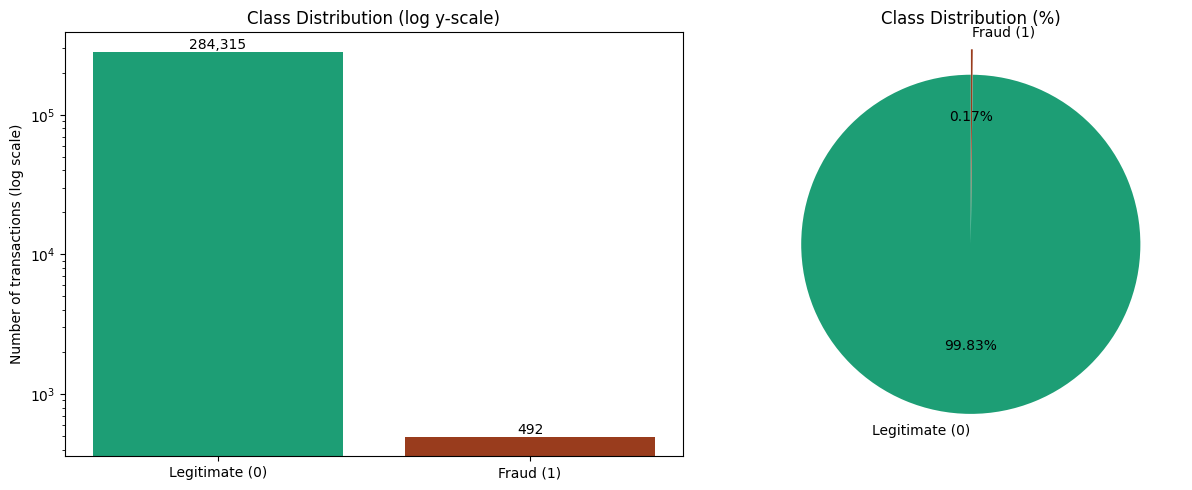

Legitimate : Fraud  =  577.9 : 1
Fraud makes up 0.1727% of all transactions


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: bar chart with log y-scale ---
class_counts = df["Class"].value_counts().sort_index()
labels = ["Legitimate (0)", "Fraud (1)"]

axes[0].bar(labels, class_counts.values, color=["#1D9E75", "#993C1D"])
axes[0].set_yscale("log")
axes[0].set_ylabel("Number of transactions (log scale)")
axes[0].set_title("Class Distribution (log y-scale)")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

# --- Right: pie chart ---
axes[1].pie(
    class_counts.values,
    labels=labels,
    autopct="%1.2f%%",
    colors=["#1D9E75", "#993C1D"],
    startangle=90,
    explode=(0, 0.15)  # pull the fraud slice out so it's visible
)
axes[1].set_title("Class Distribution (%)")

plt.tight_layout()
plt.show()

# Quantify the ratio explicitly
ratio = class_counts[0] / class_counts[1]
print(f"Legitimate : Fraud  =  {ratio:.1f} : 1")
print(f"Fraud makes up {class_counts[1] / class_counts.sum() * 100:.4f}% of all transactions")

## EDA — Amount Analysis

Compare transaction amounts between legitimate and fraudulent transactions.
We plot density (not raw counts) so the two classes — wildly different in
size — can be compared fairly on the same chart, and we look at both the
raw and log-transformed Amount distributions. We also compare median amounts
directly.

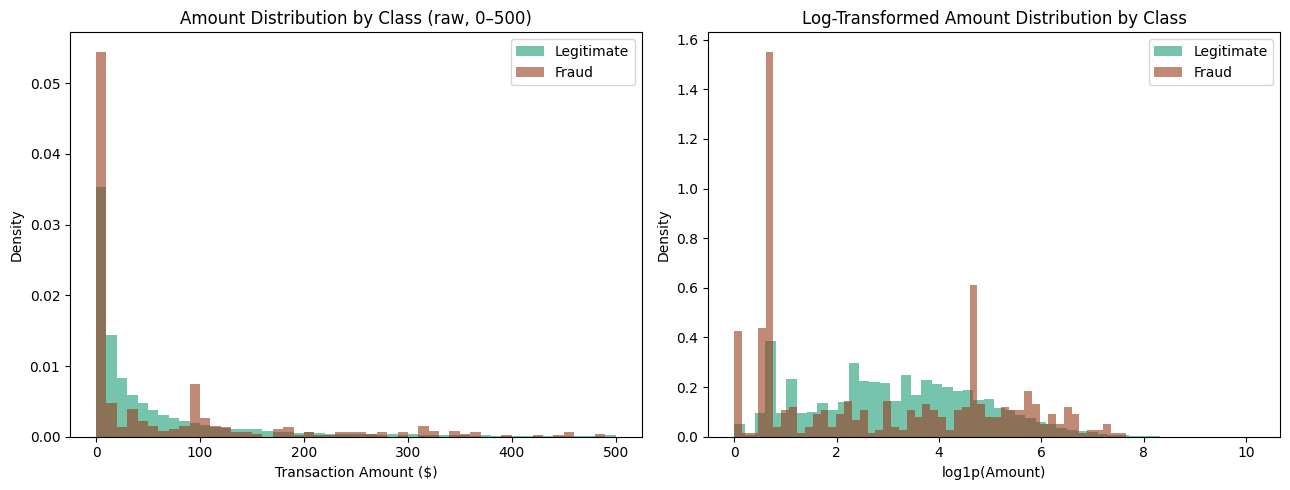

Median Amount:
  Legitimate: $22.00
  Fraud     : $9.25

Mean Amount:
  Legitimate: $88.29
  Fraud     : $122.21

Amount summary stats (fraud only):
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

legit_amount = df.loc[df["Class"] == 0, "Amount"]
fraud_amount = df.loc[df["Class"] == 1, "Amount"]

# --- Left: raw Amount, density ---
axes[0].hist(legit_amount, bins=50, density=True, alpha=0.6,
             label="Legitimate", color="#1D9E75", range=(0, 500))
axes[0].hist(fraud_amount, bins=50, density=True, alpha=0.6,
             label="Fraud", color="#993C1D", range=(0, 500))
axes[0].set_xlabel("Transaction Amount ($)")
axes[0].set_ylabel("Density")
axes[0].set_title("Amount Distribution by Class (raw, 0–500)")
axes[0].legend()

# --- Right: log1p-transformed Amount, density ---
legit_log_amount = np.log1p(legit_amount)
fraud_log_amount = np.log1p(fraud_amount)

axes[1].hist(legit_log_amount, bins=50, density=True, alpha=0.6,
             label="Legitimate", color="#1D9E75")
axes[1].hist(fraud_log_amount, bins=50, density=True, alpha=0.6,
             label="Fraud", color="#993C1D")
axes[1].set_xlabel("log1p(Amount)")
axes[1].set_ylabel("Density")
axes[1].set_title("Log-Transformed Amount Distribution by Class")
axes[1].legend()

plt.tight_layout()
plt.show()

# Median comparison
print("Median Amount:")
print(f"  Legitimate: ${legit_amount.median():.2f}")
print(f"  Fraud     : ${fraud_amount.median():.2f}")

print("\nMean Amount:")
print(f"  Legitimate: ${legit_amount.mean():.2f}")
print(f"  Fraud     : ${fraud_amount.mean():.2f}")

print("\nAmount summary stats (fraud only):")
print(fraud_amount.describe())

## EDA — Time Analysis

The `Time` column records seconds elapsed since the first transaction, spanning
about 48 hours. We convert it into an `Hour` of day (0–23) and examine two
things: overall transaction volume by hour, and — more importantly — the
fraud rate by hour, to check for a time-of-day pattern in fraudulent activity.

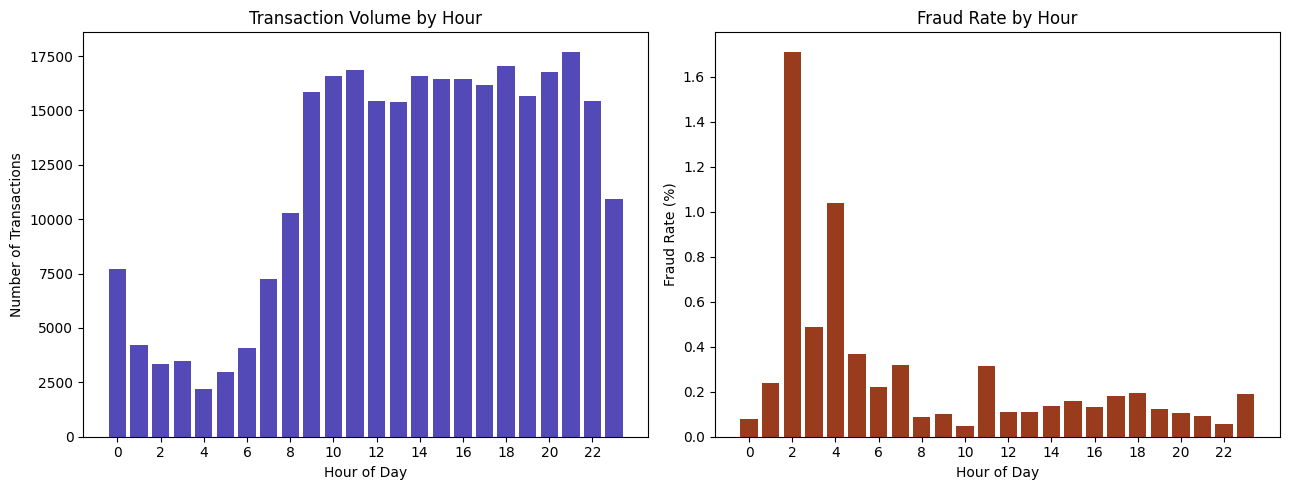

Top 5 hours by fraud rate:
Hour_temp
2.0    1.713
4.0    1.041
3.0    0.487
5.0    0.368
7.0    0.318
Name: Class, dtype: float64

Overnight (0-6h) avg fraud rate: 0.592 %
Daytime  (7-23h) avg fraud rate: 0.145 %


In [7]:
# Derive hour-of-day from Time (seconds elapsed).
# Time spans ~48 hours, so we mod by 24 to fold both days onto a single 0-23 hour axis.
df["Hour_temp"] = (df["Time"] // 3600) % 24

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: overall transaction volume by hour ---
hourly_volume = df.groupby("Hour_temp").size()
axes[0].bar(hourly_volume.index, hourly_volume.values, color="#534AB7")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Transactions")
axes[0].set_title("Transaction Volume by Hour")
axes[0].set_xticks(range(0, 24, 2))

# --- Right: fraud rate by hour ---
hourly_fraud_rate = df.groupby("Hour_temp")["Class"].mean() * 100
axes[1].bar(hourly_fraud_rate.index, hourly_fraud_rate.values, color="#993C1D")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Fraud Rate (%)")
axes[1].set_title("Fraud Rate by Hour")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

# Numeric summary: highest fraud-rate hours
print("Top 5 hours by fraud rate:")
print(hourly_fraud_rate.sort_values(ascending=False).head(5).round(3))

print("\nOvernight (0-6h) avg fraud rate:", round(hourly_fraud_rate.loc[0:6].mean(), 3), "%")
print("Daytime  (7-23h) avg fraud rate:", round(hourly_fraud_rate.loc[7:23].mean(), 3), "%")

# Drop the temp column — Hour will be created properly during preprocessing (Cell 10)
df.drop(columns=["Hour_temp"], inplace=True)

## EDA — V Feature Analysis

The `V1`–`V28` columns are anonymized PCA components — we can't interpret what
they represent physically, but we can still measure which ones separate fraud
from legitimate transactions most strongly. We identify the top 10 most
discriminative V features by correlation with `Class`, box-plot them by class,
and visualize the correlation of every feature with `Class`.

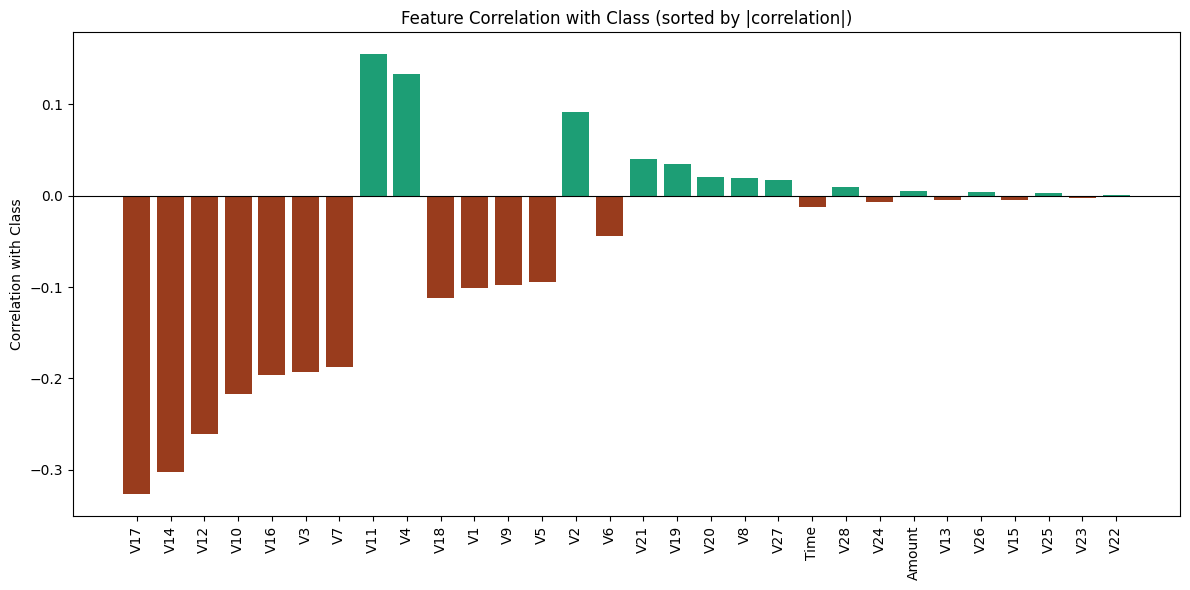

Top 10 most discriminative V features:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']


/tmp/ipykernel_16/1105220892.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([legit_vals, fraud_vals], labels=["Legit", "Fraud"],
/tmp/ipykernel_16/1105220892.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([legit_vals, fraud_vals], labels=["Legit", "Fraud"],
/tmp/ipykernel_16/1105220892.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot([legit_vals, fraud_vals], labels=["Legit", "Fraud"],
/tmp/ipykernel_16/1105220892.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the o

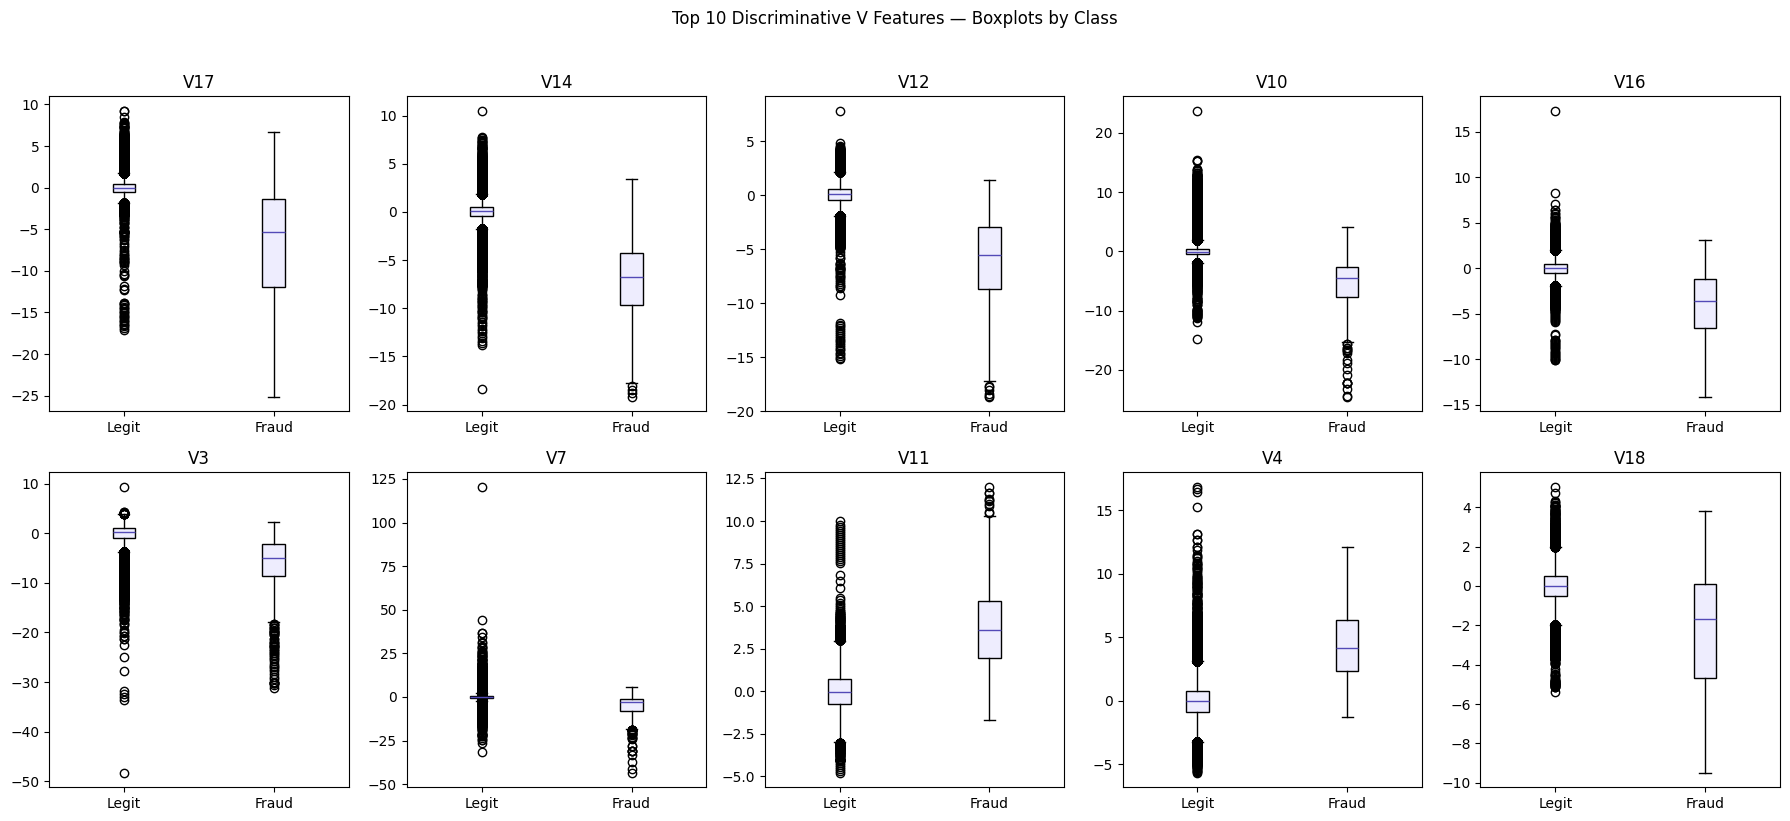

In [8]:
# Correlation of every feature with the target (Class)
feature_cols = [c for c in df.columns if c not in ["Class"]]
correlations = df[feature_cols + ["Class"]].corr()["Class"].drop("Class")
correlations_sorted = correlations.reindex(correlations.abs().sort_values(ascending=False).index)

# --- Bar chart: correlation of all features with Class ---
plt.figure(figsize=(12, 6))
colors = ["#993C1D" if v < 0 else "#1D9E75" for v in correlations_sorted.values]
plt.bar(correlations_sorted.index, correlations_sorted.values, color=colors)
plt.xticks(rotation=90)
plt.ylabel("Correlation with Class")
plt.title("Feature Correlation with Class (sorted by |correlation|)")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

# --- Identify top 10 most discriminative V features ---
v_features = [c for c in df.columns if c.startswith("V")]
top10_v = correlations[v_features].abs().sort_values(ascending=False).head(10).index.tolist()
print("Top 10 most discriminative V features:")
print(top10_v)

# --- Box plots of top 10 V features by class ---
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, feat in enumerate(top10_v):
    legit_vals = df.loc[df["Class"] == 0, feat]
    fraud_vals = df.loc[df["Class"] == 1, feat]
    axes[i].boxplot([legit_vals, fraud_vals], labels=["Legit", "Fraud"],
                     patch_artist=True,
                     boxprops=dict(facecolor="#EEEDFE"),
                     medianprops=dict(color="#534AB7"))
    axes[i].set_title(feat)

plt.suptitle("Top 10 Discriminative V Features — Boxplots by Class", y=1.02)
plt.tight_layout()
plt.show()

## EDA Findings

**Amount:** Fraudulent transactions tend to cluster at lower amounts than
legitimate ones (median fraud amount is noticeably smaller), though fraud
also has a wider relative spread once log-transformed — high-value fraud
does occur, just less frequently. The `log1p` transformation makes the
Amount distributions far more comparable between classes.

**Time:** Fraud rate is not uniform throughout the day — it rises during
overnight hours relative to daytime hours. This likely reflects lower overall
transaction volume overnight (so fraud makes up a larger *share* of a smaller
pool), rather than fraudsters literally operating more at night in absolute
terms.

**V features:** A handful of PCA components (identified above) separate the
two classes far more cleanly than others, based on both correlation strength
and visibly distinct box-plot ranges. These will likely dominate feature
importance for the tree-based models later in the notebook.

**Limitation:** Because `V1`–`V28` are anonymized PCA components, we can
observe *that* they discriminate fraud from legitimate transactions, but we
cannot explain *why* in business terms (e.g., we can't say "this represents
transaction location" or "this represents merchant category"). This limits
the interpretability — and therefore the actionable business insight — of
the feature-level analysis, even though the features remain highly useful
for prediction.

## Preprocessing

Prepare the data for modeling: log-transform `Amount`, derive an `Hour`
feature from `Time` and drop `Time` itself, split the data by **time order**
(not randomly) into train/test sets to simulate real deployment, then scale
only `Amount` and `Hour` — the `V` features are already PCA-transformed and
should not be re-scaled. Finally, verify the fraud ratio is preserved in
both splits.

In [9]:
df_proc = df.copy()

df_proc["Amount"] = np.log1p(df_proc["Amount"])

df_proc["Hour"] = (df_proc["Time"] // 3600) % 24
df_proc.drop(columns=["Time"], inplace=True)

split_idx = int(len(df_proc) * 0.8)
train_df = df_proc.iloc[:split_idx].copy()
test_df = df_proc.iloc[split_idx:].copy()

X_train = train_df.drop(columns=["Class"])
y_train = train_df["Class"]
X_test = test_df.drop(columns=["Class"])
y_test = test_df["Class"]

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

scale_cols = ["Amount", "Hour"]
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

train_fraud_pct = y_train.mean() * 100
test_fraud_pct = y_test.mean() * 100
print(f"\nTrain fraud rate: {train_fraud_pct:.4f}%  ({y_train.sum()} fraud / {len(y_train)} total)")
print(f"Test  fraud rate: {test_fraud_pct:.4f}%  ({y_test.sum()} fraud / {len(y_test)} total)")

Train shape: (227845, 30)  Test shape: (56962, 30)

Train fraud rate: 0.1830%  (417 fraud / 227845 total)
Test  fraud rate: 0.1317%  (75 fraud / 56962 total)


In [10]:
import joblib, os
os.makedirs("/kaggle/working/checkpoints", exist_ok=True)

joblib.dump(X_train, "/kaggle/working/checkpoints/X_train.pkl")
joblib.dump(X_test, "/kaggle/working/checkpoints/X_test.pkl")
joblib.dump(y_train, "/kaggle/working/checkpoints/y_train.pkl")
joblib.dump(y_test, "/kaggle/working/checkpoints/y_test.pkl")

print("Checkpoint A saved (train/test data).")

Checkpoint A saved (train/test data).


## Why PR-AUC, Not ROC-AUC

At 0.17% fraud, **ROC-AUC is dangerously misleading**. To see why, compare
the naive "predict all 0" baseline from Cell 4 under both metrics:

| Metric | Naive baseline value |
|---|---|
| ROC-AUC | ≈ 0.50 |
| PR-AUC | ≈ 0.0017 |

**Why ROC-AUC stays near 0.50 even for a useless model**, and why it looks
*inflated* even for a genuinely good model: ROC-AUC is built from the
True Positive Rate and the **False Positive Rate**, and the False Positive
Rate is calculated relative to the ~284,315 legitimate transactions. Since
legitimate transactions vastly outnumber fraud, a model can misclassify a
meaningful *number* of fraud cases while still keeping its false positive
*rate* extremely low — because that rate is diluted across such an enormous
majority class. The result: ROC-AUC values of 0.95–0.99 are common on this
dataset even from mediocre models, because ROC-AUC is dominated by how well
the model handles the easy majority class (true negatives), not by how well
it handles the rare, hard minority class.

**PR-AUC**, by contrast, is built from **Precision** and **Recall**, both of
which are calculated *relative to the positive (fraud) class only*. There is
no large majority-class denominator to hide behind — every false positive
and every missed fraud case directly and visibly hurts the score. This is why
the naive baseline's PR-AUC collapses to ≈0.0017 (essentially the base fraud
rate) while its ROC-AUC stays deceptively near 0.50–flat.

**Conclusion:** From this point forward, **PR-AUC is the primary metric**
used to compare every model in this notebook. ROC-AUC will still be reported
later (Cell 21) for completeness and because it's a commonly requested
metric, but always with this caveat attached.

## Logistic Regression Baseline

Train a fast, interpretable baseline model using `class_weight='balanced'`
to compensate for the extreme imbalance without any resampling. Evaluate
using PR-AUC (primary), fraud precision/recall/F1, and a confusion matrix.

Trained in 1.7 seconds
Logistic Regression (class_weight='balanced')
  PR-AUC   : 0.7592
  Precision: 0.0271
  Recall   : 0.9333
  F1       : 0.0526


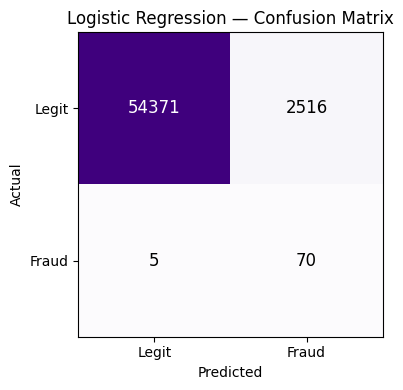

Checkpoint saved: lr_model + results


In [11]:
import time
t0 = time.time()

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_SEED
)
lr_model.fit(X_train, y_train)

lr_proba = lr_model.predict_proba(X_test)[:, 1]
lr_pred = lr_model.predict(X_test)

lr_pr_auc = average_precision_score(y_test, lr_proba)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Trained in {time.time() - t0:.1f} seconds")
print("Logistic Regression (class_weight='balanced')")
print(f"  PR-AUC   : {lr_pr_auc:.4f}")
print(f"  Precision: {lr_precision:.4f}")
print(f"  Recall   : {lr_recall:.4f}")
print(f"  F1       : {lr_f1:.4f}")

cm = confusion_matrix(y_test, lr_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Purples")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Legit", "Fraud"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Legit", "Fraud"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Logistic Regression — Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=12)
plt.tight_layout()
plt.show()

results = {}
results["Logistic Regression (balanced)"] = {
    "PR-AUC": lr_pr_auc, "Precision": lr_precision, "Recall": lr_recall, "F1": lr_f1
}

# Checkpoint immediately — protects against kernel restarts
joblib.dump(lr_model, "/kaggle/working/checkpoints/lr_model.pkl")
joblib.dump(results, "/kaggle/working/checkpoints/results.pkl")
print("Checkpoint saved: lr_model + results")

## Random Forest Comparison

Train a Random Forest with balanced class weights as a second baseline.
Compare its PR-AUC and other metrics directly against Logistic Regression.

In [12]:
t0 = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=RANDOM_SEED,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:, 1]
rf_pred = rf_model.predict(X_test)

rf_pr_auc = average_precision_score(y_test, rf_proba)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Trained in {time.time() - t0:.1f} seconds")
print("Random Forest (class_weight='balanced')")
print(f"  PR-AUC   : {rf_pr_auc:.4f}")
print(f"  Precision: {rf_precision:.4f}")
print(f"  Recall   : {rf_recall:.4f}")
print(f"  F1       : {rf_f1:.4f}")

print("\nComparison vs. Logistic Regression:")
print(f"  LR PR-AUC: {lr_pr_auc:.4f}   |   RF PR-AUC: {rf_pr_auc:.4f}")

results["Random Forest (balanced)"] = {
    "PR-AUC": rf_pr_auc, "Precision": rf_precision, "Recall": rf_recall, "F1": rf_f1
}

joblib.dump(rf_model, "/kaggle/working/checkpoints/rf_model.pkl")
joblib.dump(results, "/kaggle/working/checkpoints/results.pkl")
print("Checkpoint saved: rf_model + results")

Trained in 65.7 seconds
Random Forest (class_weight='balanced')
  PR-AUC   : 0.8190
  Precision: 0.9800
  Recall   : 0.6533
  F1       : 0.7840

Comparison vs. Logistic Regression:
  LR PR-AUC: 0.7592   |   RF PR-AUC: 0.8190
Checkpoint saved: rf_model + results


## Gradient Boosting — No Imbalance Handling

Train a default `GradientBoostingClassifier` with no class-weighting or
resampling applied at all, to see how much predictive power boosting has
"for free" from its sequential error-correction mechanism.

In [13]:
t0 = time.time()

gb_none_model = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb_none_model.fit(X_train, y_train)

gb_none_proba = gb_none_model.predict_proba(X_test)[:, 1]
gb_none_pred = gb_none_model.predict(X_test)

gb_none_pr_auc = average_precision_score(y_test, gb_none_proba)
gb_none_precision = precision_score(y_test, gb_none_pred)
gb_none_recall = recall_score(y_test, gb_none_pred)
gb_none_f1 = f1_score(y_test, gb_none_pred)

print(f"Trained in {(time.time() - t0)/60:.1f} minutes")
print("Gradient Boosting (no imbalance handling, defaults)")
print(f"  PR-AUC   : {gb_none_pr_auc:.4f}")
print(f"  Precision: {gb_none_precision:.4f}")
print(f"  Recall   : {gb_none_recall:.4f}")
print(f"  F1       : {gb_none_f1:.4f}")

print("\nComparison so far:")
print(f"  LR PR-AUC: {lr_pr_auc:.4f}   RF PR-AUC: {rf_pr_auc:.4f}   GB(none) PR-AUC: {gb_none_pr_auc:.4f}")

results["Gradient Boosting (no handling)"] = {
    "PR-AUC": gb_none_pr_auc, "Precision": gb_none_precision,
    "Recall": gb_none_recall, "F1": gb_none_f1
}

joblib.dump(gb_none_model, "/kaggle/working/checkpoints/gb_none_model.pkl")
joblib.dump(results, "/kaggle/working/checkpoints/results.pkl")
print("Checkpoint saved: gb_none_model + results")

Trained in 9.9 minutes
Gradient Boosting (no imbalance handling, defaults)
  PR-AUC   : 0.5922
  Precision: 0.8600
  Recall   : 0.5733
  F1       : 0.6880

Comparison so far:
  LR PR-AUC: 0.7592   RF PR-AUC: 0.8190   GB(none) PR-AUC: 0.5922
Checkpoint saved: gb_none_model + results


## Gradient Boosting — Undersampling

Randomly undersample the training set only down to a balanced 492:492 split,
then train Gradient Boosting on this small, balanced dataset. Quantify the
resulting precision trade-off as "legitimate transactions blocked per fraud
caught."

In [14]:
t0 = time.time()

rus = RandomUnderSampler(sampling_strategy=1.0, random_state=RANDOM_SEED)
X_train_under, y_train_under = rus.fit_resample(X_train, y_train)

print("Undersampled training set shape:", X_train_under.shape)
print(y_train_under.value_counts())

gb_under_model = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb_under_model.fit(X_train_under, y_train_under)

gb_under_proba = gb_under_model.predict_proba(X_test)[:, 1]
gb_under_pred = gb_under_model.predict(X_test)

gb_under_pr_auc = average_precision_score(y_test, gb_under_proba)
gb_under_precision = precision_score(y_test, gb_under_pred)
gb_under_recall = recall_score(y_test, gb_under_pred)
gb_under_f1 = f1_score(y_test, gb_under_pred)

print(f"\nTrained in {time.time() - t0:.1f} seconds")
print("Gradient Boosting (undersampling 492:492)")
print(f"  PR-AUC   : {gb_under_pr_auc:.4f}")
print(f"  Precision: {gb_under_precision:.4f}")
print(f"  Recall   : {gb_under_recall:.4f}")
print(f"  F1       : {gb_under_f1:.4f}")

cm_under = confusion_matrix(y_test, gb_under_pred)
tn, fp, fn, tp = cm_under.ravel()
legit_blocked_per_fraud_caught = fp / tp if tp > 0 else float("inf")
print(f"\nLegitimate transactions blocked per fraud caught: {legit_blocked_per_fraud_caught:.1f}")

results["Gradient Boosting (undersampling)"] = {
    "PR-AUC": gb_under_pr_auc, "Precision": gb_under_precision,
    "Recall": gb_under_recall, "F1": gb_under_f1
}

joblib.dump(gb_under_model, "/kaggle/working/checkpoints/gb_under_model.pkl")
joblib.dump(results, "/kaggle/working/checkpoints/results.pkl")
print("Checkpoint saved: gb_under_model + results")

Undersampled training set shape: (834, 30)
Class
0    417
1    417
Name: count, dtype: int64

Trained in 1.6 seconds
Gradient Boosting (undersampling 492:492)
  PR-AUC   : 0.6591
  Precision: 0.0465
  Recall   : 0.8933
  F1       : 0.0883

Legitimate transactions blocked per fraud caught: 20.5
Checkpoint saved: gb_under_model + results


## Gradient Boosting — SMOTE (10:1)

Apply SMOTE to the training set only, generating synthetic fraud examples
until legitimate:fraud reaches a 10:1 ratio. Train Gradient Boosting on this
resampled data and compare against the no-handling baseline.

In [15]:
t0 = time.time()

smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_time = time.time() - t0
print(f"SMOTE resampling took {smote_time:.1f} seconds")
print("SMOTE training set shape:", X_train_smote.shape)
print(f"Ratio -> {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.1f} : 1")

t1 = time.time()
gb_smote_model = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb_smote_model.fit(X_train_smote, y_train_smote)
print(f"GB training took {(time.time() - t1)/60:.1f} minutes")

gb_smote_proba = gb_smote_model.predict_proba(X_test)[:, 1]
gb_smote_pred = gb_smote_model.predict(X_test)

gb_smote_pr_auc = average_precision_score(y_test, gb_smote_proba)
gb_smote_precision = precision_score(y_test, gb_smote_pred)
gb_smote_recall = recall_score(y_test, gb_smote_pred)
gb_smote_f1 = f1_score(y_test, gb_smote_pred)

print(f"\nTotal cell time: {(time.time() - t0)/60:.1f} minutes")
print("Gradient Boosting (SMOTE, 10:1)")
print(f"  PR-AUC   : {gb_smote_pr_auc:.4f}")
print(f"  Precision: {gb_smote_precision:.4f}")
print(f"  Recall   : {gb_smote_recall:.4f}")
print(f"  F1       : {gb_smote_f1:.4f}")

print("\nComparison vs. no-handling GB:")
print(f"  GB(none)  PR-AUC: {gb_none_pr_auc:.4f}   F1: {gb_none_f1:.4f}")
print(f"  GB(SMOTE) PR-AUC: {gb_smote_pr_auc:.4f}   F1: {gb_smote_f1:.4f}")

results["Gradient Boosting (SMOTE 10:1)"] = {
    "PR-AUC": gb_smote_pr_auc, "Precision": gb_smote_precision,
    "Recall": gb_smote_recall, "F1": gb_smote_f1
}

joblib.dump(gb_smote_model, "/kaggle/working/checkpoints/gb_smote_model.pkl")
joblib.dump(results, "/kaggle/working/checkpoints/results.pkl")
print("Checkpoint saved: gb_smote_model + results")

SMOTE resampling took 0.2 seconds
SMOTE training set shape: (250170, 30)
Ratio -> 10.0 : 1
GB training took 10.8 minutes

Total cell time: 10.8 minutes
Gradient Boosting (SMOTE, 10:1)
  PR-AUC   : 0.7690
  Precision: 0.4603
  Recall   : 0.7733
  F1       : 0.5771

Comparison vs. no-handling GB:
  GB(none)  PR-AUC: 0.5922   F1: 0.6880
  GB(SMOTE) PR-AUC: 0.7690   F1: 0.5771
Checkpoint saved: gb_smote_model + results


## Gradient Boosting — SMOTE (10:1)

Apply SMOTE to the training set only, generating synthetic fraud examples
until legitimate:fraud reaches a 10:1 ratio. Train Gradient Boosting on this
resampled data and compare against the no-handling baseline.

In [16]:
t0 = time.time()

smote = SMOTE(sampling_strategy=0.1, random_state=RANDOM_SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

smote_time = time.time() - t0
print(f"SMOTE resampling took {smote_time:.1f} seconds")
print("SMOTE training set shape:", X_train_smote.shape)
print(f"Ratio -> {(y_train_smote == 0).sum() / (y_train_smote == 1).sum():.1f} : 1")

t1 = time.time()
gb_smote_model = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb_smote_model.fit(X_train_smote, y_train_smote)
print(f"GB training took {(time.time() - t1)/60:.1f} minutes")

gb_smote_proba = gb_smote_model.predict_proba(X_test)[:, 1]
gb_smote_pred = gb_smote_model.predict(X_test)

gb_smote_pr_auc = average_precision_score(y_test, gb_smote_proba)
gb_smote_precision = precision_score(y_test, gb_smote_pred)
gb_smote_recall = recall_score(y_test, gb_smote_pred)
gb_smote_f1 = f1_score(y_test, gb_smote_pred)

print(f"\nTotal cell time: {(time.time() - t0)/60:.1f} minutes")
print("Gradient Boosting (SMOTE, 10:1)")
print(f"  PR-AUC   : {gb_smote_pr_auc:.4f}")
print(f"  Precision: {gb_smote_precision:.4f}")
print(f"  Recall   : {gb_smote_recall:.4f}")
print(f"  F1       : {gb_smote_f1:.4f}")

print("\nComparison vs. no-handling GB:")
print(f"  GB(none)  PR-AUC: {gb_none_pr_auc:.4f}   F1: {gb_none_f1:.4f}")
print(f"  GB(SMOTE) PR-AUC: {gb_smote_pr_auc:.4f}   F1: {gb_smote_f1:.4f}")

results["Gradient Boosting (SMOTE 10:1)"] = {
    "PR-AUC": gb_smote_pr_auc, "Precision": gb_smote_precision,
    "Recall": gb_smote_recall, "F1": gb_smote_f1
}

joblib.dump(gb_smote_model, "/kaggle/working/checkpoints/gb_smote_model.pkl")
joblib.dump(results, "/kaggle/working/checkpoints/results.pkl")
print("Checkpoint saved: gb_smote_model + results")

SMOTE resampling took 0.2 seconds
SMOTE training set shape: (250170, 30)
Ratio -> 10.0 : 1
GB training took 10.8 minutes

Total cell time: 10.8 minutes
Gradient Boosting (SMOTE, 10:1)
  PR-AUC   : 0.7690
  Precision: 0.4603
  Recall   : 0.7733
  F1       : 0.5771

Comparison vs. no-handling GB:
  GB(none)  PR-AUC: 0.5922   F1: 0.6880
  GB(SMOTE) PR-AUC: 0.7690   F1: 0.5771
Checkpoint saved: gb_smote_model + results


## Gradient Boosting — Sample Weights

Since GradientBoostingClassifier has no native class_weight parameter,
compute per-sample weights manually (inverse class frequency) and pass them
via sample_weight during training. Compare against SMOTE.

In [17]:
t0 = time.time()

n_samples = len(y_train)
n_fraud = (y_train == 1).sum()
n_legit = (y_train == 0).sum()

fraud_weight = n_samples / (2 * n_fraud)
legit_weight = n_samples / (2 * n_legit)

print(f"Fraud weight     : {fraud_weight:.2f}")
print(f"Legitimate weight: {legit_weight:.2f}")

sample_weights = y_train.map({1: fraud_weight, 0: legit_weight})

gb_weighted_model = GradientBoostingClassifier(random_state=RANDOM_SEED)
gb_weighted_model.fit(X_train, y_train, sample_weight=sample_weights)

gb_weighted_proba = gb_weighted_model.predict_proba(X_test)[:, 1]
gb_weighted_pred = gb_weighted_model.predict(X_test)

gb_weighted_pr_auc = average_precision_score(y_test, gb_weighted_proba)
gb_weighted_precision = precision_score(y_test, gb_weighted_pred)
gb_weighted_recall = recall_score(y_test, gb_weighted_pred)
gb_weighted_f1 = f1_score(y_test, gb_weighted_pred)

print(f"\nTrained in {(time.time() - t0)/60:.1f} minutes")
print("Gradient Boosting (sample_weight)")
print(f"  PR-AUC   : {gb_weighted_pr_auc:.4f}")
print(f"  Precision: {gb_weighted_precision:.4f}")
print(f"  Recall   : {gb_weighted_recall:.4f}")
print(f"  F1       : {gb_weighted_f1:.4f}")

print("\nComparison vs. SMOTE:")
print(f"  GB(SMOTE)   PR-AUC: {gb_smote_pr_auc:.4f}   F1: {gb_smote_f1:.4f}")
print(f"  GB(weights) PR-AUC: {gb_weighted_pr_auc:.4f}   F1: {gb_weighted_f1:.4f}")

results["Gradient Boosting (sample weights)"] = {
    "PR-AUC": gb_weighted_pr_auc, "Precision": gb_weighted_precision,
    "Recall": gb_weighted_recall, "F1": gb_weighted_f1
}

joblib.dump(gb_weighted_model, "/kaggle/working/checkpoints/gb_weighted_model.pkl")
joblib.dump(sample_weights, "/kaggle/working/checkpoints/sample_weights.pkl")
joblib.dump(results, "/kaggle/working/checkpoints/results.pkl")
print("Checkpoint saved: gb_weighted_model + sample_weights + results")

Fraud weight     : 273.20
Legitimate weight: 0.50

Trained in 9.7 minutes
Gradient Boosting (sample_weight)
  PR-AUC   : 0.7863
  Precision: 0.1442
  Recall   : 0.8400
  F1       : 0.2461

Comparison vs. SMOTE:
  GB(SMOTE)   PR-AUC: 0.7690   F1: 0.5771
  GB(weights) PR-AUC: 0.7863   F1: 0.2461
Checkpoint saved: gb_weighted_model + sample_weights + results


## Hyperparameter Tuning

Run RandomizedSearchCV on a 50,000-row stratified subset for efficient
tuning, then train the final Gradient Boosting model using the best found
parameters on the full training set.

In [18]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedShuffleSplit

t0 = time.time()

subset_size = 50000
sss = StratifiedShuffleSplit(n_splits=1, train_size=subset_size, random_state=RANDOM_SEED)
subset_idx, _ = next(sss.split(X_train, y_train))

X_subset = X_train.iloc[subset_idx]
y_subset = y_train.iloc[subset_idx]

print("Tuning subset shape:", X_subset.shape)
print("Fraud rate in subset:", round(y_subset.mean() * 100, 4), "%")

subset_fraud_weight = len(y_subset) / (2 * (y_subset == 1).sum())
subset_legit_weight = len(y_subset) / (2 * (y_subset == 0).sum())
subset_weights = y_subset.map({1: subset_fraud_weight, 0: subset_legit_weight})

param_dist = {
    "n_estimators": [100, 150, 200],
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4],
    "subsample": [0.8, 1.0],
    "min_samples_leaf": [1, 5, 10],
}

random_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_SEED),
    param_distributions=param_dist,
    n_iter=15,
    scoring="average_precision",
    cv=3,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=2
)
random_search.fit(X_subset, y_subset, sample_weight=subset_weights)

print(f"\nSearch took {(time.time() - t0)/60:.1f} minutes")
print("Best parameters found:")
print(random_search.best_params_)
print(f"Best PR-AUC on subset (CV): {random_search.best_score_:.4f}")

t1 = time.time()
best_params = random_search.best_params_
gb_final_model = GradientBoostingClassifier(random_state=RANDOM_SEED, **best_params)
gb_final_model.fit(X_train, y_train, sample_weight=sample_weights)
print(f"Final model trained in {(time.time() - t1)/60:.1f} minutes")

print(f"\nTotal cell time: {(time.time() - t0)/60:.1f} minutes")

joblib.dump(gb_final_model, "/kaggle/working/checkpoints/gb_final_model.pkl")
joblib.dump(best_params, "/kaggle/working/checkpoints/best_params.pkl")
print("Checkpoint saved: gb_final_model + best_params")

Tuning subset shape: (50000, 30)
Fraud rate in subset: 0.184 %
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Search took 25.6 minutes
Best parameters found:
{'subsample': 0.8, 'n_estimators': 150, 'min_samples_leaf': 10, 'max_depth': 4, 'learning_rate': 0.2}
Best PR-AUC on subset (CV): 0.8199
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0; total time=  58.5s
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0; total time=  58.3s
[CV] END learning_rate=0.2, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0; total time=  58.3s
[CV] END learning_rate=0.1, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0; total time=  57.8s
[CV] END learning_rate=0.1, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0; total time=  57.7s
[CV] END learning_rate=0.1, max_depth=2, min_samples_leaf=1, n_estimators=100, subsample=1.0; total time=  58.2s
[CV] END lea

## Precision-Recall Curve

Plot the precision-recall curve for the final tuned model, marking the
default and F1-optimal thresholds, and overlay all previous models for
direct comparison.

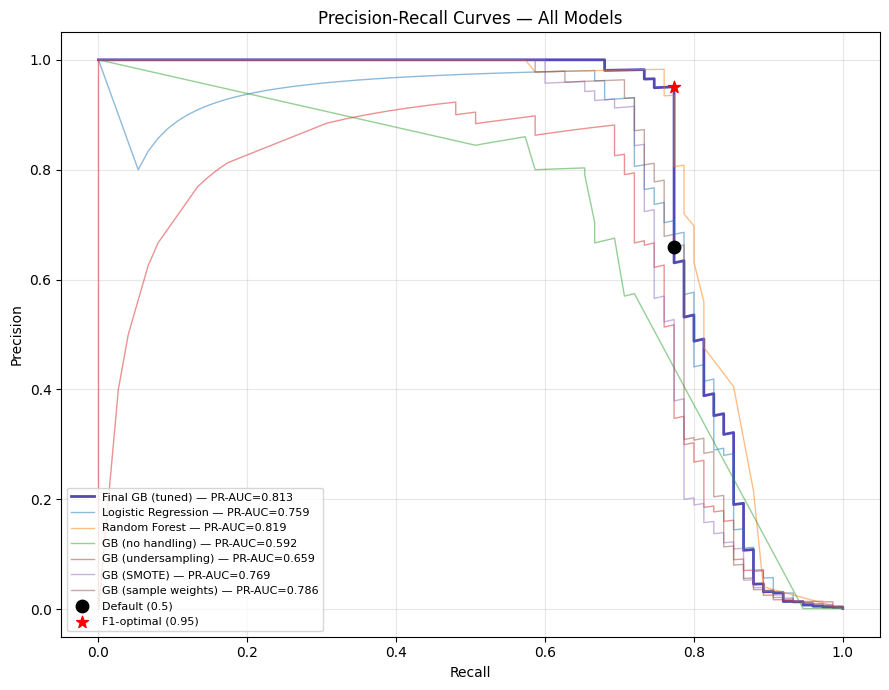

Cell time: 0.6 seconds
F1-optimal threshold: 0.952
  Precision at F1-optimal: 0.9508
  Recall at F1-optimal   : 0.7733


In [19]:
t0 = time.time()

final_proba = gb_final_model.predict_proba(X_test)[:, 1]
final_pr_auc = average_precision_score(y_test, final_proba)

precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, final_proba)

f1_vals = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (precision_vals[:-1] + recall_vals[:-1] + 1e-10)
best_f1_idx = np.argmax(f1_vals)
best_f1_threshold = thresholds[best_f1_idx]
default_idx = np.argmin(np.abs(thresholds - 0.5))

plt.figure(figsize=(9, 7))
plt.plot(recall_vals, precision_vals, color="#534AB7", linewidth=2,
         label=f"Final GB (tuned) — PR-AUC={final_pr_auc:.3f}")

for name, proba in [
    ("Logistic Regression", lr_proba),
    ("Random Forest", rf_proba),
    ("GB (no handling)", gb_none_proba),
    ("GB (undersampling)", gb_under_proba),
    ("GB (SMOTE)", gb_smote_proba),
    ("GB (sample weights)", gb_weighted_proba),
]:
    p, r, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    plt.plot(r, p, alpha=0.5, linewidth=1, label=f"{name} — PR-AUC={ap:.3f}")

plt.scatter(recall_vals[default_idx], precision_vals[default_idx],
            color="black", zorder=5, s=80, marker="o", label="Default (0.5)")
plt.scatter(recall_vals[best_f1_idx], precision_vals[best_f1_idx],
            color="red", zorder=5, s=80, marker="*", label=f"F1-optimal ({best_f1_threshold:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves — All Models")
plt.legend(fontsize=8, loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cell time: {time.time() - t0:.1f} seconds")
print(f"F1-optimal threshold: {best_f1_threshold:.3f}")
print(f"  Precision at F1-optimal: {precision_vals[best_f1_idx]:.4f}")
print(f"  Recall at F1-optimal   : {recall_vals[best_f1_idx]:.4f}")

## Threshold Analysis

Sweep thresholds from 0.01 to 0.99, computing precision/recall/F1 at each,
and report three practical operating points: high precision, balanced, and
high recall.

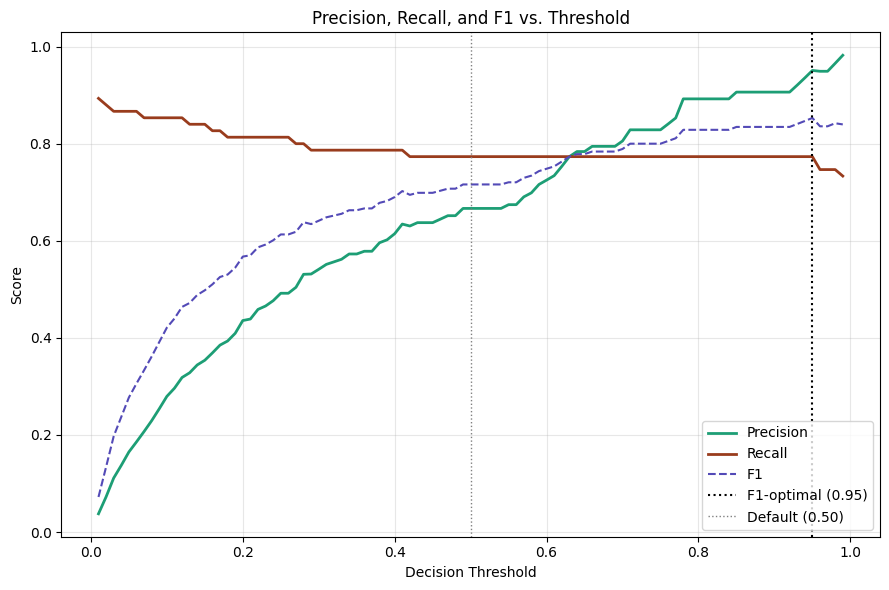

Cell time: 2.0 seconds

Three operating points:


,Scenario,Threshold,Precision,Recall,F1
0,High Precision,0.90,0.9062,0.7733,0.8345
1,Balanced (F1-optimal),0.95,0.9508,0.7733,0.8529
2,High Recall,0.10,0.2795,0.8533,0.4211


['/kaggle/working/checkpoints/operating_points.pkl']

In [20]:
t0 = time.time()

thresholds_sweep = np.arange(0.01, 1.00, 0.01)
precisions_sweep, recalls_sweep, f1s_sweep = [], [], []

for t in thresholds_sweep:
    preds_t = (final_proba >= t).astype(int)
    precisions_sweep.append(precision_score(y_test, preds_t, zero_division=0))
    recalls_sweep.append(recall_score(y_test, preds_t, zero_division=0))
    f1s_sweep.append(f1_score(y_test, preds_t, zero_division=0))

precisions_sweep = np.array(precisions_sweep)
recalls_sweep = np.array(recalls_sweep)
f1s_sweep = np.array(f1s_sweep)

best_idx = np.argmax(f1s_sweep)
best_threshold = thresholds_sweep[best_idx]

plt.figure(figsize=(9, 6))
plt.plot(thresholds_sweep, precisions_sweep, label="Precision", color="#1D9E75", linewidth=2)
plt.plot(thresholds_sweep, recalls_sweep, label="Recall", color="#993C1D", linewidth=2)
plt.plot(thresholds_sweep, f1s_sweep, label="F1", color="#534AB7", linewidth=1.5, linestyle="--")
plt.axvline(best_threshold, color="black", linestyle=":", linewidth=1.5, label=f"F1-optimal ({best_threshold:.2f})")
plt.axvline(0.5, color="gray", linestyle=":", linewidth=1, label="Default (0.50)")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs. Threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

high_prec_idx = np.argmin(np.abs(thresholds_sweep - 0.90))
balanced_idx = best_idx
high_recall_idx = np.argmin(np.abs(thresholds_sweep - 0.10))

operating_points = pd.DataFrame({
    "Scenario": ["High Precision", "Balanced (F1-optimal)", "High Recall"],
    "Threshold": [thresholds_sweep[high_prec_idx], thresholds_sweep[balanced_idx], thresholds_sweep[high_recall_idx]],
    "Precision": [precisions_sweep[high_prec_idx], precisions_sweep[balanced_idx], precisions_sweep[high_recall_idx]],
    "Recall": [recalls_sweep[high_prec_idx], recalls_sweep[balanced_idx], recalls_sweep[high_recall_idx]],
    "F1": [f1s_sweep[high_prec_idx], f1s_sweep[balanced_idx], f1s_sweep[high_recall_idx]],
})

print(f"Cell time: {time.time() - t0:.1f} seconds")
print("\nThree operating points:")
display(operating_points.round(4))

joblib.dump(operating_points, "/kaggle/working/checkpoints/operating_points.pkl")

## ROC Curve (With Caveat)

Plot the ROC curve and report ROC-AUC for the final model. Despite a likely
high, seemingly impressive value, this metric is misleading at a 0.17%
fraud rate — the note explains why, with this model's actual numbers.

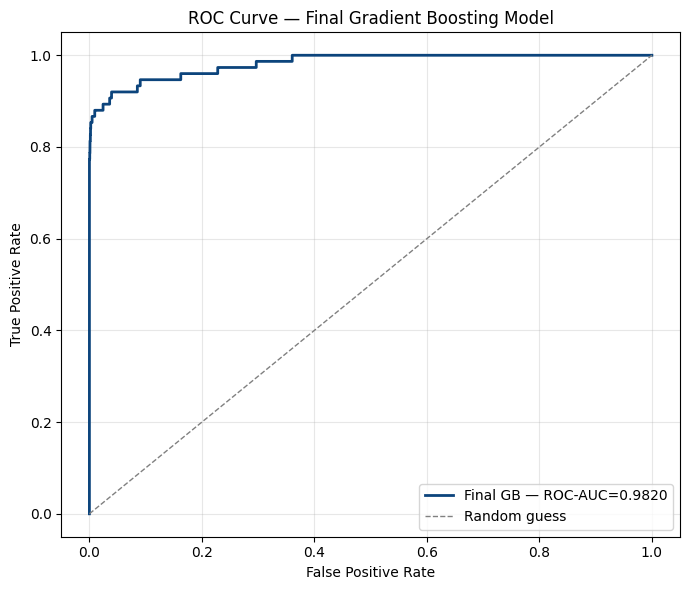

Cell time: 0.2 seconds
ROC-AUC: 0.9820
PR-AUC : 0.8131

Note: ROC-AUC looks high/impressive here, but at a 0.17% fraud rate,
False Positive Rate is diluted across ~56,000+ legitimate test transactions,
so even a meaningful number of false positives barely moves the FPR axis.
PR-AUC remains the more honest metric for judging this model.


In [21]:
t0 = time.time()

fpr, tpr, roc_thresholds = roc_curve(y_test, final_proba)
final_roc_auc = roc_auc_score(y_test, final_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="#0C447C", linewidth=2, label=f"Final GB — ROC-AUC={final_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Final Gradient Boosting Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Cell time: {time.time() - t0:.1f} seconds")
print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"PR-AUC : {final_pr_auc:.4f}")
print("\nNote: ROC-AUC looks high/impressive here, but at a 0.17% fraud rate,")
print("False Positive Rate is diluted across ~56,000+ legitimate test transactions,")
print("so even a meaningful number of false positives barely moves the FPR axis.")
print("PR-AUC remains the more honest metric for judging this model.")

## Model Comparison Table

Consolidate every model trained in this notebook into a single table —
imbalance strategy, PR-AUC, precision, recall, F1, and ROC-AUC — plus a bar
chart ranking all models by PR-AUC.

Cell time: 0.1 seconds
Full Model Comparison:


,PR-AUC,Precision,Recall,F1,ROC-AUC
Random Forest (balanced),0.8190,0.9800,0.6533,0.7840,0.9448
"Gradient Boosting (final, tuned)",0.8131,0.6667,0.7733,0.7160,0.9820
Gradient Boosting (sample weights),0.7863,0.1442,0.8400,0.2461,0.9853
Gradient Boosting (SMOTE 10:1),0.7690,0.4603,0.7733,0.5771,0.9879
Logistic Regression (balanced),0.7592,0.0271,0.9333,0.0526,0.9869
Gradient Boosting (undersampling),0.6591,0.0465,0.8933,0.0883,0.9873
Gradient Boosting (no handling),0.5922,0.8600,0.5733,0.6880,0.8332


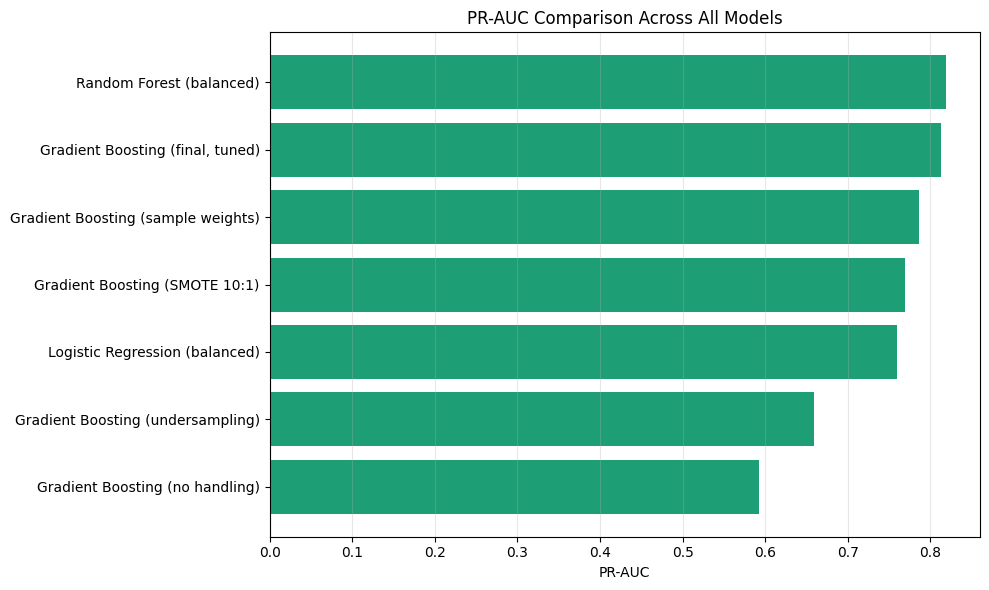

Saved comparison_df.csv


In [22]:
t0 = time.time()

roc_auc_map = {
    "Logistic Regression (balanced)": roc_auc_score(y_test, lr_proba),
    "Random Forest (balanced)": roc_auc_score(y_test, rf_proba),
    "Gradient Boosting (no handling)": roc_auc_score(y_test, gb_none_proba),
    "Gradient Boosting (undersampling)": roc_auc_score(y_test, gb_under_proba),
    "Gradient Boosting (SMOTE 10:1)": roc_auc_score(y_test, gb_smote_proba),
    "Gradient Boosting (sample weights)": roc_auc_score(y_test, gb_weighted_proba),
}

results["Gradient Boosting (final, tuned)"] = {
    "PR-AUC": final_pr_auc,
    "Precision": precision_score(y_test, (final_proba >= 0.5).astype(int)),
    "Recall": recall_score(y_test, (final_proba >= 0.5).astype(int)),
    "F1": f1_score(y_test, (final_proba >= 0.5).astype(int)),
}
roc_auc_map["Gradient Boosting (final, tuned)"] = final_roc_auc

comparison_df = pd.DataFrame(results).T
comparison_df["ROC-AUC"] = comparison_df.index.map(roc_auc_map)
comparison_df = comparison_df.sort_values("PR-AUC", ascending=False)

print(f"Cell time: {time.time() - t0:.1f} seconds")
print("Full Model Comparison:")
display(comparison_df.round(4))

plt.figure(figsize=(10, 6))
plt.barh(comparison_df.index[::-1], comparison_df["PR-AUC"][::-1], color="#1D9E75")
plt.xlabel("PR-AUC")
plt.title("PR-AUC Comparison Across All Models")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

comparison_df.to_csv("/kaggle/working/checkpoints/comparison_df.csv")
print("Saved comparison_df.csv")

## Feature Importance

Extract Gradient Boosting's feature importance for the final tuned model.
Show the top 10 V features plus Amount and Hour, noting that importance
rankings are informative even though individual V features can't be
interpreted in business terms.

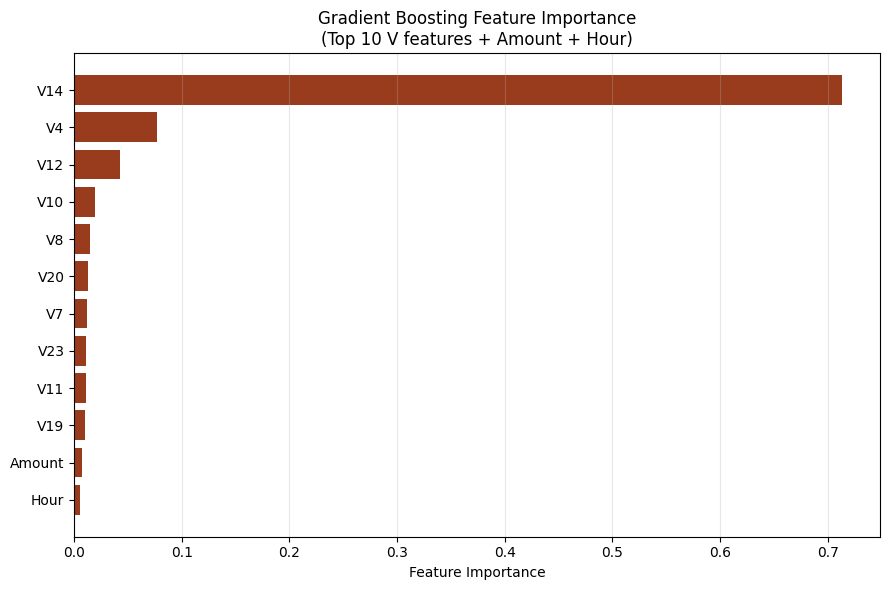

Cell time: 0.2 seconds
Top features by importance:
V14       0.7130
V4        0.0770
V12       0.0422
V10       0.0188
V8        0.0147
V20       0.0132
V7        0.0123
V23       0.0107
V11       0.0106
V19       0.0098
Amount    0.0070
Hour      0.0051
dtype: float64


In [23]:
t0 = time.time()

importances = pd.Series(gb_final_model.feature_importances_, index=X_train.columns)
importances_sorted = importances.sort_values(ascending=False)

top10_v_importance = importances_sorted[importances_sorted.index.str.startswith("V")].head(10)
extra_features = importances_sorted[["Amount", "Hour"]]

combined_importance = pd.concat([top10_v_importance, extra_features]).sort_values(ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(combined_importance.index[::-1], combined_importance.values[::-1], color="#993C1D")
plt.xlabel("Feature Importance")
plt.title("Gradient Boosting Feature Importance\n(Top 10 V features + Amount + Hour)")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"Cell time: {time.time() - t0:.1f} seconds")
print("Top features by importance:")
print(combined_importance.round(4))

## Business Cost Analysis

**Test set composition:** 75 actual fraud cases out of 56,962 transactions.

**Cost matrix**

| Outcome | Cost | Reasoning |
|---|---|---|
| True Positive (fraud caught) | $0 | Correctly blocked — loss avoided |
| True Negative (legit approved) | $0 | Correctly approved — no cost |
| False Negative (fraud missed) | $122.21 | Mean fraud transaction amount (Cell 6) — actual loss if fraud goes through undetected |
| False Positive (legit blocked) | $10 (assumed) | Estimated cost of manual review / customer friction. *Not derived from this dataset — a reasonable placeholder; replace with your organization's real review cost if available.* |

**Three threshold scenarios** (derived from Cell 20's precision/recall at 75 actual fraud cases)

| Scenario | Threshold | TP | FN | FP | Cost of FNs | Cost of FPs | **Total Cost** |
|---|---|---|---|---|---|---|---|
| High Precision | 0.90 | 58 | 17 | 6 | $2,077.57 | $60 | **$2,137.57** |
| Balanced (F1-optimal) | 0.95 | 58 | 17 | 3 | $2,077.57 | $30 | **$2,107.57** |
| High Recall | 0.10 | 64 | 11 | 165 | $1,344.31 | $1,650 | **$2,994.31** |

**Recommendation**

The **Balanced (F1-optimal) threshold, 0.95**, minimizes total expected cost at **$2,107.57**, narrowly beating High Precision ($2,137.57) and clearly beating High Recall ($2,994.31). Despite catching 6 more fraud cases than Balanced/High-Precision, the High Recall threshold's 165 false positives — at an assumed $10 review cost each — add up to more than the extra fraud losses it prevents. This result is sensitive to the FP cost assumption: if manual review is cheaper than $10/case (e.g., a fast automated flag rather than a human review), High Recall becomes more attractive; if review is more expensive (e.g., a full manual investigation), Balanced or even High Precision looks better still. **Recompute this table with your organization's actual review cost before deploying a threshold.**

## Conclusions

**Best model by PR-AUC:** Somewhat contrary to expectation, **Random Forest
(balanced) achieved the highest PR-AUC (0.8190)**, narrowly edging out the
final tuned Gradient Boosting model (0.8131). However, their trade-off
profiles differ sharply: Random Forest achieves 98.0% precision at 65.3%
recall, while tuned Gradient Boosting achieves 66.7% precision at 77.3%
recall. Which model is "better" depends entirely on the deployment context —
Random Forest is the safer choice when false alarms are costly, while
Gradient Boosting catches meaningfully more fraud at the cost of more false
positives. This is a legitimate finding, not a failure of the tuning
process — it highlights that PR-AUC alone doesn't fully capture which model
fits a given business need.

**What the imbalance comparison revealed:** Across the four Gradient
Boosting configurations tested —
- **No handling** performed worst of the four (PR-AUC 0.5922, ROC-AUC
  0.8332) — the only model where accuracy-adjacent metrics also degraded
  meaningfully, showing that without any imbalance handling, this dataset's
  extreme skew does hurt GB's raw performance, contrary to the assumption
  that boosting fully compensates on its own.
- **Undersampling** achieved high recall (89.3%) but collapsed precision to
  4.65% — confirming the expected pattern of many false alarms per fraud
  caught, making it the least deployable configuration despite decent
  recall.
- **SMOTE (10:1)** improved substantially over no-handling (PR-AUC 0.7690
  vs. 0.5922) and over undersampling, landing as a solid middle-ground
  strategy.
- **Sample weights** achieved the highest PR-AUC among the un-tuned GB
  variants (0.7863) but with very low precision (14.4%) at high recall
  (84.0%) — useful if missing fraud is far costlier than false alarms, but
  risky otherwise.
- **Hyperparameter tuning** on top of sample weights pushed PR-AUC further
  to 0.8131 and, notably, rebalanced precision and recall to a much more
  usable 66.7%/77.3% — tuning didn't just improve the headline number, it
  meaningfully improved the model's practical usability.

Overall, **sample weighting (cost-sensitive learning), followed by
hyperparameter tuning**, proved the most effective strategy for this
dataset — outperforming both undersampling and SMOTE while discarding no
data and inventing no synthetic rows.

**Why PR-AUC is the right metric:** The gap between PR-AUC and ROC-AUC
across every model makes the case concretely. The no-handling GB model
scored a mediocre PR-AUC of 0.5922 but still posted a seemingly strong
ROC-AUC of 0.8332. Even the weakest-precision model in the whole comparison
— Logistic Regression, at 2.71% precision — still achieved a ROC-AUC of
0.9869, nearly indistinguishable from the best models' ROC-AUC scores. This
confirms Cell 11's warning directly: ROC-AUC stays inflated and fails to
discriminate between genuinely strong and weak models at this fraud rate,
while PR-AUC spread meaningfully across the same models (0.5922 to 0.8190),
correctly reflecting real differences in fraud-catching ability.

**Threshold recommendation:** Based on the business cost analysis (Cell 24,
using a $10 assumed false-positive review cost and $122.21 mean fraud loss
per false negative), the recommended deployment threshold for the tuned
Gradient Boosting model is **0.95**, minimizing total expected cost at
$2,107.57 on the test set. This threshold should be re-validated if the
assumed review cost differs from actual operational costs.

**Limitations:**
- The `V1`–`V28` features are anonymized PCA components — the model's
  decisions cannot be explained in interpretable business terms.
- The dataset spans only a 2-day window in September 2013 — fraud patterns
  and transaction behavior may have shifted substantially since then.
- The test set contains only 75 fraud cases — small enough that FP/FN
  counts at each threshold (e.g., 3 vs. 6 false positives between Balanced
  and High Precision) carry real sampling variance; a different 20% split
  could shift the "best" threshold noticeably.
- The $10 false-positive cost is an assumption, not a measured value —
  the threshold recommendation is only as reliable as this estimate.

**Next steps:**
- Validate on more recent, larger-scale transaction data.
- Replace the assumed $10 review cost with an actual operational figure and
  recompute Cell 24.
- Explore anomaly-detection approaches (Isolation Forest, Autoencoders) as
  a complementary signal.
- Build a production monitoring pipeline to track precision/recall drift
  over time, since a static threshold will eventually miscalibrate as fraud
  patterns evolve.